# Lab 5: Linear Regression using Gradient Descent


# Task 1: Load and Explore the Dataset

## Dataset
**Dataset Name:** Student Performance Dataset (Mathematics)

**Source:** UCI Machine Learning Repository

### Why this Dataset?
The Student Performance dataset was selected because it contains real-world academic, demographic, and social information about students. It is widely used for regression problems and is suitable for predicting student performance using Linear Regression with Gradient Descent.

### Initial Exploration
The dataset was loaded using Pandas and explored by:
- Viewing the first five records
- Checking dataset dimensions
- Listing column names
- Examining data types
- Checking missing values
- Checking duplicate records
- Generating summary statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
student_data = pd.read_csv("student-mat.csv", sep=";")

In [3]:
student_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
print("Shape:", student_data.shape)

Shape: (395, 33)


In [5]:
student_data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [6]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [7]:
student_data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [8]:
print(student_data.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [9]:
print("Duplicate Rows:", student_data.duplicated().sum())

Duplicate Rows: 0


# Task 2: Data Preprocessing

The dataset was preprocessed before training the Gradient Descent model.

The preprocessing steps included:

- Checked for missing values.
- Checked and removed duplicate records (if any).
- Encoded categorical variables using One-Hot Encoding.
- Selected input features (**X**) and target variable (**G3**).
- Applied **StandardScaler** to normalize the feature values.

Feature scaling is particularly important for Gradient Descent because it ensures that all features contribute equally during optimization and helps the algorithm converge faster.

In [10]:
print(student_data.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [11]:
print("Duplicate Rows:", student_data.duplicated().sum())

Duplicate Rows: 0


In [12]:
student_data.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

In [13]:
student_data = pd.get_dummies(student_data, drop_first=True)

In [14]:
X = student_data.drop("G3", axis=1)
y = student_data["G3"]

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Task 3: Feature Selection

The target variable selected for this experiment is **G3 (Final Grade)** because the objective is to predict the student's final academic performance.

All remaining columns were used as input features after preprocessing and encoding. The target variable was removed from the feature set to prevent data leakage during model training.

In [17]:
# Input Features
X = student_data.drop("G3", axis=1)

# Target Variable
y = student_data["G3"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (395, 41)
Target Shape: (395,)


# Task 4: Train-Test Split

The dataset was divided into **training** and **testing** sets using an **80:20 ratio**. The training set is used to train the Gradient Descent model, while the testing set is used to evaluate its performance on unseen data.

The `random_state` parameter was set to **42** to ensure that the data split remains consistent and reproducible every time the code is executed.

- **Training Data:** 80% of the dataset
- **Testing Data:** 20% of the dataset

This split helps evaluate how well the trained model generalizes to new data and prevents overfitting.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 316
Testing Samples: 79


# Task 5: Linear Regression using Gradient Descent

Gradient Descent was implemented from scratch to optimize the parameters of the Linear Regression model. The algorithm starts with initial weights and bias, predicts the target values, calculates the prediction error, computes the gradients of the cost function, and updates the parameters iteratively until convergence.

The Mean Squared Error (MSE) cost function was minimized using Gradient Descent. The learning rate controls the step size of each update, while the number of iterations determines how long the optimization process continues.

In [19]:
import numpy as np

def gradient_descent(X, y, learning_rate=0.01, iterations=1000):

    m, n = X.shape

    weights = np.zeros(n)
    bias = 0

    cost_history = []

    for i in range(iterations):

        # Prediction
        y_pred = np.dot(X, weights) + bias

        # Error
        error = y_pred - y

        # Gradients
        dw = (1/m) * np.dot(X.T, error)
        db = (1/m) * np.sum(error)

        # Update parameters
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db

        # Cost (MSE)
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)

    return weights, bias, cost_history

In [20]:
weights, bias, cost_history = gradient_descent(
    X_train,
    y_train,
    learning_rate=0.01,
    iterations=1000
)

In [21]:
print("Bias:")
print(bias)

print("\nWeights:")
print(weights)

Bias:
10.338063724419579

Weights:
[-0.17075026  0.08338118 -0.18126462  0.02708963 -0.03801335 -0.18299739
  0.28158907 -0.04067     0.1969491  -0.15826306  0.08961896  0.05348431
  0.42890806  1.1529908   3.19176826  0.03854881  0.17043245  0.04470998
 -0.01173542 -0.07031797 -0.1174269  -0.06600171 -0.01690858  0.05635413
  0.08952964  0.13308739 -0.11104193 -0.0593258  -0.25811982  0.12542359
 -0.09048023  0.03935036 -0.05186192  0.3271577   0.11241284  0.07547857
 -0.24161591 -0.09426471  0.04710706 -0.05108845 -0.21607977]


# Task 6: Effect of Learning Rate on Gradient Descent

The Gradient Descent algorithm was trained using different learning rates (0.001, 0.01, and 0.1) to study their effect on convergence.

- **Learning Rate = 0.001:** The model converged slowly because the parameter updates were very small.
- **Learning Rate = 0.01:** The model showed smooth and stable convergence, providing a good balance between speed and accuracy.
- **Learning Rate = 0.1:** The model converged much faster. However, very large learning rates can overshoot the minimum and may lead to unstable convergence.

Comparing multiple learning rates helps identify a value that achieves faster convergence while maintaining stable optimization.

In [22]:
learning_rates = [0.001, 0.01, 0.1]

results = {}

for lr in learning_rates:
    weights, bias, cost_history = gradient_descent(
        X_train,
        y_train,
        learning_rate=lr,
        iterations=1000
    )

    results[lr] = cost_history

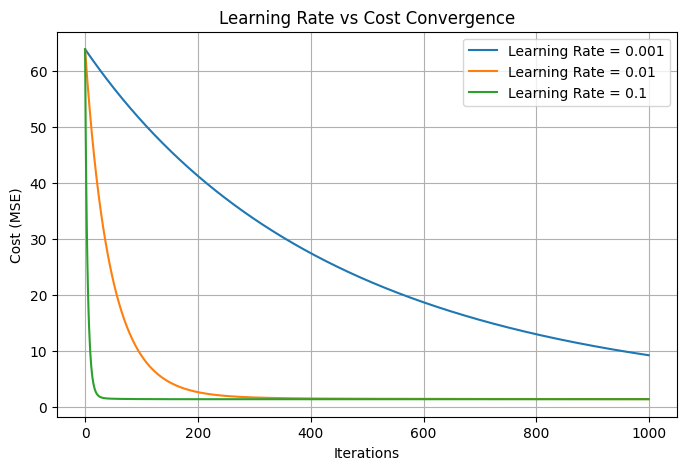

In [23]:
plt.figure(figsize=(8,5))

for lr in learning_rates:
    plt.plot(results[lr], label=f"Learning Rate = {lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Learning Rate vs Cost Convergence")
plt.legend()
plt.grid(True)
plt.show()

# Task 7: Model Evaluation

The Gradient Descent model was evaluated using standard regression metrics on the testing dataset.

The following evaluation metrics were calculated:

- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**
- **R² Score**

These metrics measure the prediction accuracy of the regression model. Lower values of MAE, MSE, and RMSE indicate smaller prediction errors, while a higher R² score indicates that the model explains a larger proportion of the variance in the target variable.

In [24]:
# Train the final model using the best learning rate

weights, bias, cost_history = gradient_descent(
    X_train,
    y_train,
    learning_rate=0.1,
    iterations=1000
)

In [25]:
# Predict final grades

y_pred = np.dot(X_test, weights) + bias

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Evaluation
-----------------------
MAE : 1.6466767987443716
MSE : 5.656666564702515
RMSE: 2.3783747738114185
R² Score: 0.7241329663496046


# Task 8: Interpretation of Results

The Gradient Descent algorithm successfully minimized the cost function and converged during training. The convergence graph showed that different learning rates affected the speed of optimization. A learning rate of **0.1** achieved the fastest stable convergence, while **0.001** converged slowly and **0.01** provided a balanced convergence rate.

The evaluation metrics indicate that the trained model performs well on the testing dataset. The **MAE of 1.65** shows that the average prediction error is approximately 1.65 marks. The **RMSE of 2.38** indicates that the prediction error is relatively low compared to the overall grade range (0–20). The **R² score of 0.724** shows that the model explains about **72.4%** of the variation in students' final grades, demonstrating good predictive capability.

Overall, Gradient Descent successfully optimized the Linear Regression model, and the selected learning rate produced stable convergence with satisfactory prediction accuracy.

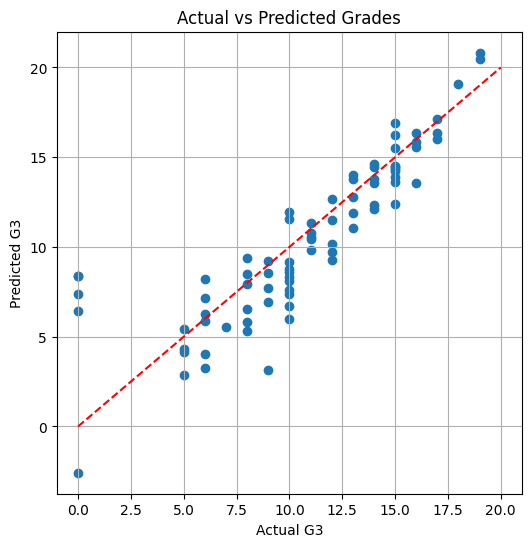

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Grades")
plt.grid(True)
plt.show()